# Planetary composites: AE versus CE, surface-referenced tilt
This extends `composite_breakdown` without changing it. Every selected day is translated to its fitted surface centre; the mean constituent centre at depth defines the new **surface-to-depth tilt vector**. Its length is the composite tilt distance. This definition also works for individual profiles; compositing estimates its population mean and can cancel opposing tilts. The length of the mean vector is **not** the mean length of individual vectors.

Geographic east/north components use the same ROMS grid-angle rotation as `seacofs_tilt_tools`. Bearings point **towards the deeper centre**, clockwise from north. They are reversed relative to the previous deep-to-shallow tilt convention. Existing `TiltDis` and `TiltDir` are never used to select or measure these tilts.

The main comparison includes all available fitted depths, including beyond 1,000 m. Independent depth support, whole-eddy bootstrap intervals, and a fixed-membership check accompany it. Intervals describe sampling uncertainty, not ESP fitting error or dependence between distinct eddies.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subdirectory')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
ESP_ROOT = Path("/home/z5297792/ESP_zonodo")
if str(ESP_ROOT) not in sys.path:
    sys.path.insert(0, str(ESP_ROOT))
import functions as esp
import seacofs_tilt_tools as tilt
pd.set_option('display.max_columns', 60)

# Reuse the dataset's directional-radius helper for the full composite refit.
DATASET_SRC = ANALYSIS.parent/'seacofs_eddy_dataset_modular'/'src'
if str(DATASET_SRC) not in sys.path:
    sys.path.insert(0, str(DATASET_SRC))
import composite_breakdown_tools as cbt

import planetary_composite_tools as pct


In [2]:
DOMINANCE_FACTOR = 2.0
ELLIPSE_FRAC = 1.0
MIN_PLAN_DEPTH_M = 3000.0
USE_PV_CACHE = True
SPLIT_DEPTH_M = 1000.0
TARGET_DEPTHS_M = [200., 500., 1000., 1500., 2000.]
BOOTSTRAPS = 500
SEED = 731
MIN_DIRECTION_DISTANCE_KM = 0.0  # zero vectors always have undefined direction
MIN_PLOT_EDDIES = 2  # plotting threshold only; all estimates remain in tables
WIDTH_KM, RES_KM = 400., 10.
RUN_VELOCITY_COMPOSITES = True
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
surface, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
surface = tilt.add_pv_gradient_terms(surface, grid, core_mean=True, frac=ELLIPSE_FRAC,
    surface_method='esp_gaussian', averaging='nonlinear', use_cache=USE_PV_CACHE)
vertical = tilt.load_vert(paths)
planetary = surface.loc[(surface.topo_plan_ratio <= -np.log(DOMINANCE_FACTOR)) &
    (surface.h >= MIN_PLAN_DEPTH_M) & surface.Cyc.isin(['AE','CE'])].copy()
profile_audit, centred_profiles = pct.prepare_profiles(planetary, vertical, SPLIT_DEPTH_M)
display(profile_audit.groupby(['Cyc','profile_status'], dropna=False).size().rename('eddy_days'))
display(profile_audit.groupby(['Cyc','extent_group'],dropna=False).agg(
    eddy_days=('Day','size'), eddies=('Eddy','nunique'), median_max_depth=('max_fit_depth_m','median')))


Cyc  profile_status      
AE   no valid surface fit     188
     usable                  6158
CE   no valid surface fit     119
     usable                  2131
Name: eddy_days, dtype: int64

eddy_days  eddies  median_max_depth
Cyc extent_group                                     
AE  deep               4924     448       3930.053268
    shallow            1234     359        327.440851
    NaN                 188     124               NaN
CE  deep               1780     357       4460.447022
    shallow             351     165        407.922192
    NaN                 119      75               NaN

## Depth-extent groups and reconstruction
`shallow` means an eddy-day's deepest valid fit is ≤ the split depth; `deep` means > it. The classification is made **before** reconstruction or display-depth restrictions. A track can contribute days to both groups as its observed extent changes. These are observed fit extents, not certified physical eddy bottoms: fitting failures can truncate profiles.

The `all` group is the baseline and overlaps the other two groups. Days receive equal weight, matching the breakdown notebook. By default the actual ESP velocity composites are computed, and centre statistics use precisely the levels that contributed finite velocity. Turning off reconstruction allows faster centre-only exploration, using valid fitted centres instead; that mode is explicitly labelled below.


In [3]:
a = np.arange(-WIDTH_KM/2, WIDTH_KM/2 + RES_KM/2, RES_KM)
X, Y = np.meshgrid(a, a)
results = {}
for cohort in ['all','shallow','deep']:
    for cyc in ['AE','CE']:
        selected = profile_audit.loc[profile_audit.Cyc.eq(cyc) & profile_audit.profile_status.eq('usable')].copy()
        if cohort != 'all': selected = selected.loc[selected.extent_group.eq(cohort)]
        if selected.empty:
            print(cohort,cyc,': no usable profiles'); continue
        if RUN_VELOCITY_COMPOSITES:
            u,v,depths,counts,support,audit,members = pct.composite_days(
                selected,vertical,X,Y,return_centres=True,esp=esp)
            field = dict(u=u,v=v,depths=depths,counts=counts,support=support,audit=audit)
        else:
            members = centred_profiles.merge(selected[['Eddy','Day']],on=['Eddy','Day'],validate='many_to_one')[['Eddy','Day','Depth','xc','yc']]
            field = {}
        members = pct.geographic_members(members, grid.angle)
        stats, boot = pct.summarise(members,BOOTSTRAPS,SEED)
        results[cohort,cyc] = dict(members=members,stats=stats,bootstrap=boot,**field)
        print(cohort,cyc,':',len(members),'contributing levels;',members.Eddy.nunique(),'eddies')
if not results: raise ValueError('No usable planetary profiles')
print('Mode:', 'finite ESP contributors' if RUN_VELOCITY_COMPOSITES else 'valid fitted centres only')
centre_stats = pd.concat([r['stats'].assign(cohort=g,Cyc=c) for (g,c),r in results.items()],ignore_index=True)
centre_members = pd.concat([r['members'].assign(cohort=g,Cyc=c) for (g,c),r in results.items()],ignore_index=True)
display(centre_stats)


Reconstructed 100 eddy-days
Reconstructed 200 eddy-days
Reconstructed 300 eddy-days
Reconstructed 400 eddy-days
Reconstructed 500 eddy-days
Reconstructed 600 eddy-days
Reconstructed 700 eddy-days
Reconstructed 800 eddy-days
Reconstructed 900 eddy-days
Reconstructed 1000 eddy-days
Reconstructed 1100 eddy-days
Reconstructed 1200 eddy-days
Reconstructed 1300 eddy-days
Reconstructed 1400 eddy-days
Reconstructed 1500 eddy-days
Reconstructed 1600 eddy-days
Reconstructed 1700 eddy-days
Reconstructed 1800 eddy-days
Reconstructed 1900 eddy-days
Reconstructed 2000 eddy-days
Reconstructed 2100 eddy-days
Reconstructed 2200 eddy-days
Reconstructed 2300 eddy-days
Reconstructed 2400 eddy-days
Reconstructed 2500 eddy-days
Reconstructed 2600 eddy-days
Reconstructed 2700 eddy-days
Reconstructed 2800 eddy-days
Reconstructed 2900 eddy-days
Reconstructed 3000 eddy-days
Reconstructed 3100 eddy-days
Reconstructed 3200 eddy-days
Reconstructed 3300 eddy-days
Reconstructed 3400 eddy-days
Reconstructed 3500 eddy

,Depth,n_eddy_days,n_eddies,mean_east,mean_north,var_east,var_north,cov_xy,std_east,std_north,mean_east_ci_low,mean_east_ci_high,mean_north_ci_low,mean_north_ci_high,bootstrap_valid_draws,distance_km,bearing_deg,mean_member_distance_km,coherence,distance_ci_low,distance_ci_high,cohort,Cyc
0,0.000000,6158,587,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500,0.000000,NaN,0.000000,NaN,0.000000,0.000000,all,AE
1,5.879627,6158,587,-0.030247,-0.135796,18.262280,18.277972,3.997511,4.273439,4.275275,-0.182722,0.124881,-0.273917,0.004783,500,0.139124,192.557169,3.656447,0.038049,0.044494,0.296746,all,AE
2,10.725783,6158,587,-0.173826,-0.314221,29.631453,24.008776,4.737340,5.443478,4.899875,-0.383230,0.044010,-0.524162,-0.144910,500,0.359096,208.951252,4.979672,0.072112,0.195185,0.581171,all,AE
3,16.383097,6134,586,-0.278634,-0.541003,36.394131,31.580615,7.516227,6.032755,5.619663,-0.533370,-0.031674,-0.786961,-0.321756,500,0.608540,207.249971,5.934128,0.102549,0.367820,0.883515,all,AE
4,22.925581,6119,585,-0.326631,-0.749827,42.675471,36.929416,10.177393,6.532647,6.076958,-0.606016,-0.041059,-1.026338,-0.511073,500,0.817881,203.538352,6.617813,0.123588,0.563253,1.115771,all,AE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,2568.677466,1366,305,-10.282206,22.703317,1108.172022,1257.074034,149.254215,33.289218,35.455240,-13.878923,-6.619423,18.739328,26.403869,500,24.923169,335.634492,48.181602,0.517276,21.550588,28.342355,deep,CE
160,3252.716389,1282,286,-10.184917,24.028133,1240.148797,1423.193962,182.207312,35.215746,37.725243,-14.085921,-5.944297,19.674113,28.014473,500,26.097580,337.029141,51.073728,0.510979,22.193750,29.886780,deep,CE
161,3930.053268,1247,274,-10.318030,24.516960,1235.334616,1487.950751,183.662257,35.147327,38.573965,-14.450573,-5.742906,19.727850,28.610686,500,26.599681,337.176075,51.620565,0.515292,22.706592,30.341179,deep,CE
162,4460.447022,1227,267,-10.643603,24.842871,1226.718211,1463.639646,191.999089,35.024537,38.257544,-15.045075,-6.000554,20.008948,29.037020,500,27.026922,336.807921,51.573887,0.524043,22.961143,30.827531,deep,CE


## Composite tilt and depth support
Component bands are 95% pointwise whole-eddy bootstrap intervals; the covariance and variance columns quantify individual-day spread. The distance band bootstraps the **norm of each resampled mean vector**, preserving x–y covariance. Close to zero this nonnegative norm is biased upward, so use the component intervals to assess whether the mean displacement differs from zero. Direction is undefined for a zero vector.

`coherence = length(mean vector) / mean(length)` approaches zero when constituent tilts cancel and one when they point together. Sparse depths remain in the tables; plotting support is controlled above.


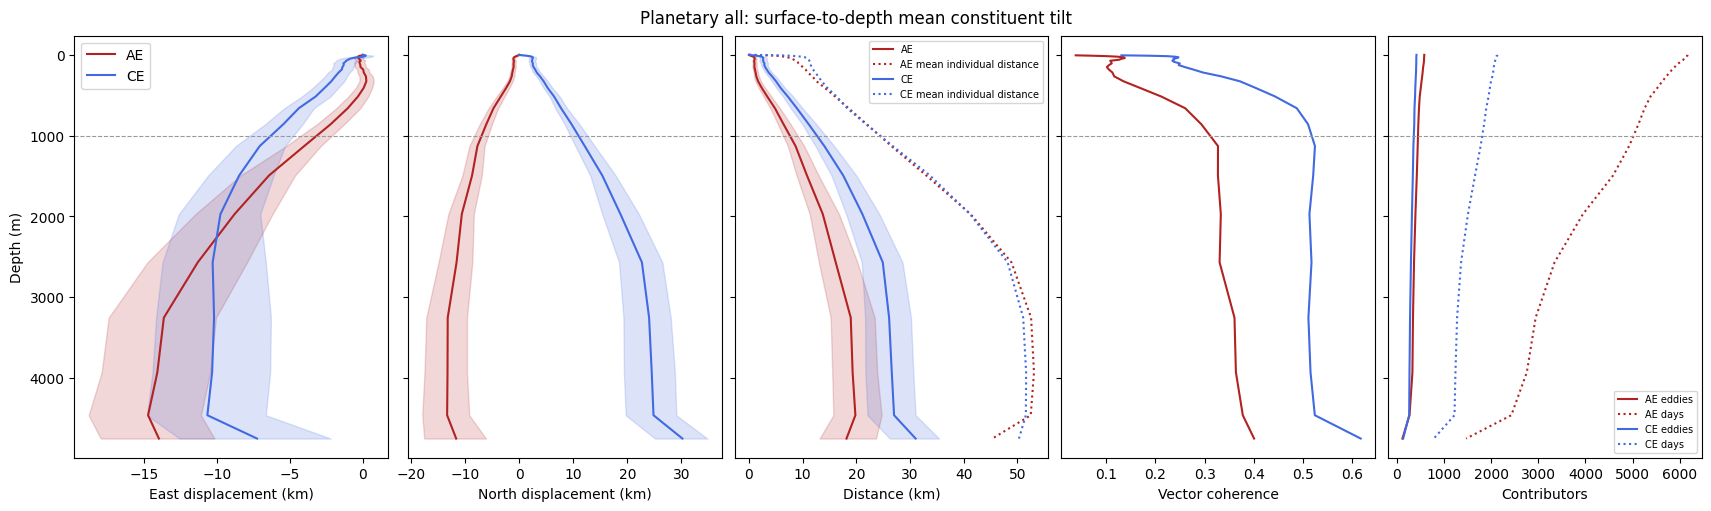

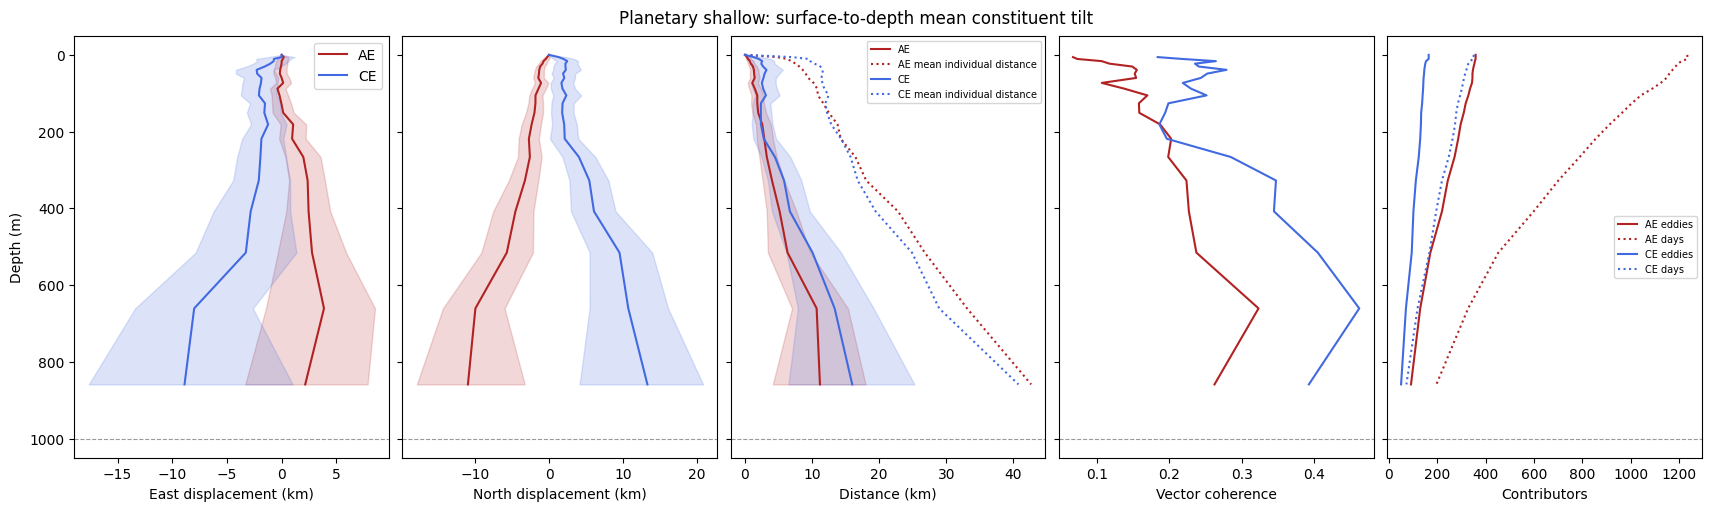

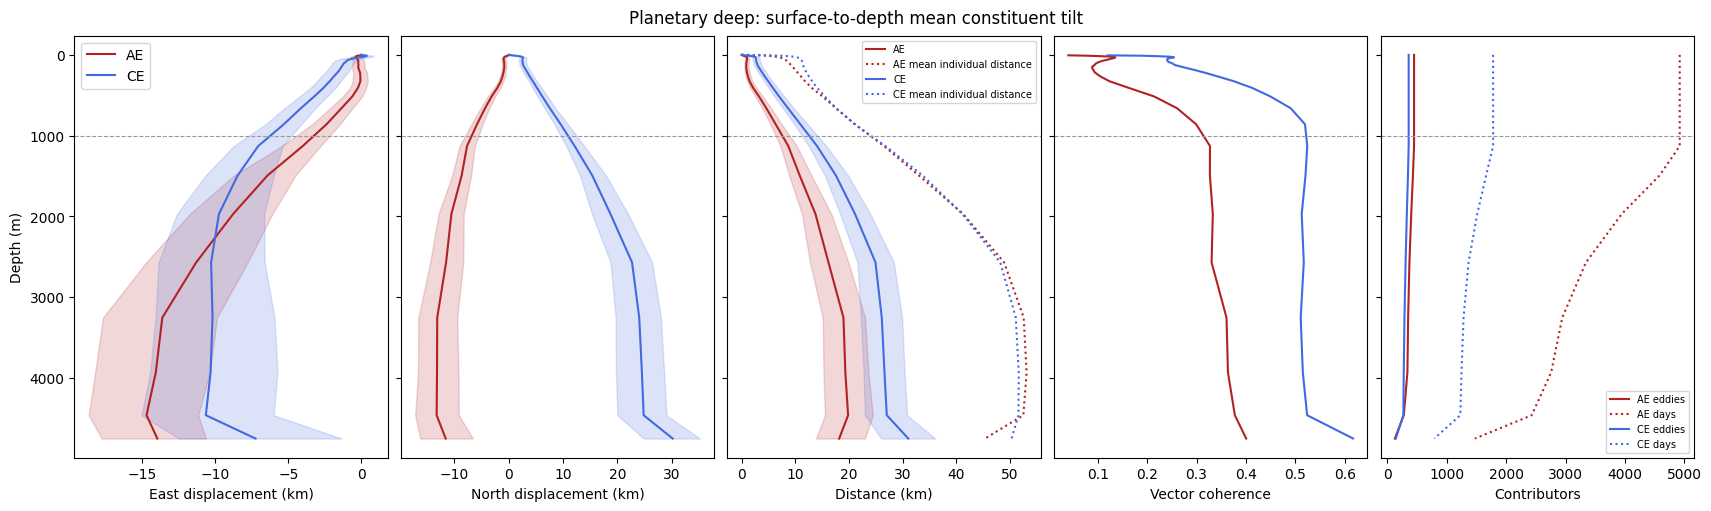

In [4]:
COLORS = {'AE':'firebrick','CE':'royalblue'}
for cohort in ['all','shallow','deep']:
    fig,axs=plt.subplots(1,5,figsize=(17,5),sharey=True,constrained_layout=True)
    for cyc in ['AE','CE']:
        if (cohort,cyc) not in results: continue
        s=results[cohort,cyc]['stats'].copy()
        ok=s.n_eddies.ge(MIN_PLOT_EDDIES)
        for ax,col,lo,hi in [(axs[0],'mean_east','mean_east_ci_low','mean_east_ci_high'),
                             (axs[1],'mean_north','mean_north_ci_low','mean_north_ci_high'),
                             (axs[2],'distance_km','distance_ci_low','distance_ci_high')]:
            ax.plot(s[col].where(ok),s.Depth,color=COLORS[cyc],label=cyc)
            ax.fill_betweenx(s.Depth,s[lo].where(ok),s[hi].where(ok),color=COLORS[cyc],alpha=.18)
        axs[2].plot(s.mean_member_distance_km.where(ok),s.Depth,':',color=COLORS[cyc],label=f'{cyc} mean individual distance')
        axs[3].plot(s.coherence.where(ok),s.Depth,color=COLORS[cyc])
        axs[4].plot(s.n_eddies,s.Depth,color=COLORS[cyc],label=f'{cyc} eddies')
        axs[4].plot(s.n_eddy_days,s.Depth,':',color=COLORS[cyc],label=f'{cyc} days')
    for ax,label in zip(axs,['East displacement (km)','North displacement (km)','Distance (km)','Vector coherence','Contributors']):
        ax.set_xlabel(label); ax.axhline(SPLIT_DEPTH_M,color='.6',ls='--',lw=.8)
    axs[0].set_ylabel('Depth (m)'); axs[0].invert_yaxis()
    axs[0].legend();axs[2].legend(fontsize=7);axs[4].legend(fontsize=7)
    fig.suptitle(f'Planetary {cohort}: surface-to-depth mean constituent tilt')
    plt.show()


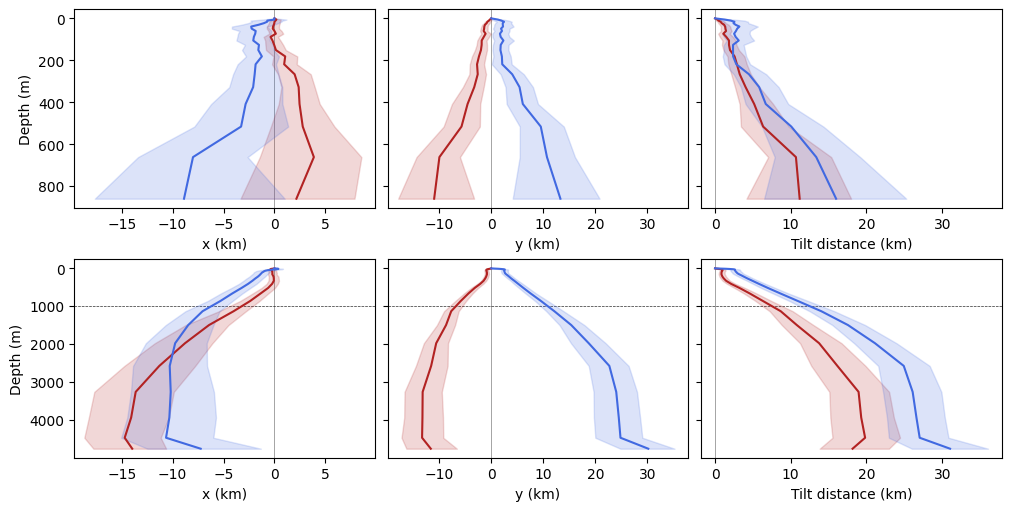

In [36]:
fig,axs=plt.subplots(2,3,figsize=(10,5),sharey=False,constrained_layout=True)
for c, cohort in enumerate(['shallow','deep']):
    for cyc in ['AE','CE']:
        if (cohort,cyc) not in results: continue
        s=results[cohort,cyc]['stats'].copy()
        ok=s.n_eddies.ge(MIN_PLOT_EDDIES)
        for r, (ax,col,lo,hi) in enumerate([(axs[c,0],'mean_east','mean_east_ci_low','mean_east_ci_high'),
                             (axs[c,1],'mean_north','mean_north_ci_low','mean_north_ci_high'),
                             (axs[c,2],'distance_km','distance_ci_low','distance_ci_high')]):
            ax.plot(s[col].where(ok),s.Depth,color=COLORS[cyc],label=cyc)
            ax.fill_betweenx(s.Depth,s[lo].where(ok),s[hi].where(ok),color=COLORS[cyc],alpha=.18)
            if r!=0: ax.set_yticklabels([])
            if c==1: ax.axhline(1000,color='k', zorder=0, alpha=.5, ls='--',lw=.5)
            ax.set_ylabel('Depth (m)' if r == 0 else ''); 
            if r == 0:
                ax.set_xlabel('x (km)')
            if r == 1:
                ax.set_xlabel('y (km)')
            if r == 2:
                ax.set_xlabel('Tilt distance (km)')
for j in range(3):
    xlim = (min(ax.get_xlim()[0] for ax in axs[:,j]),
            max(ax.get_xlim()[1] for ax in axs[:,j]))
    [ax.set_xlim(xlim) for ax in axs[:,j]]
for ax in axs.flat: ax.invert_yaxis(); ax.axvline(0,lw=.5,color='k', zorder=0, alpha=.5)


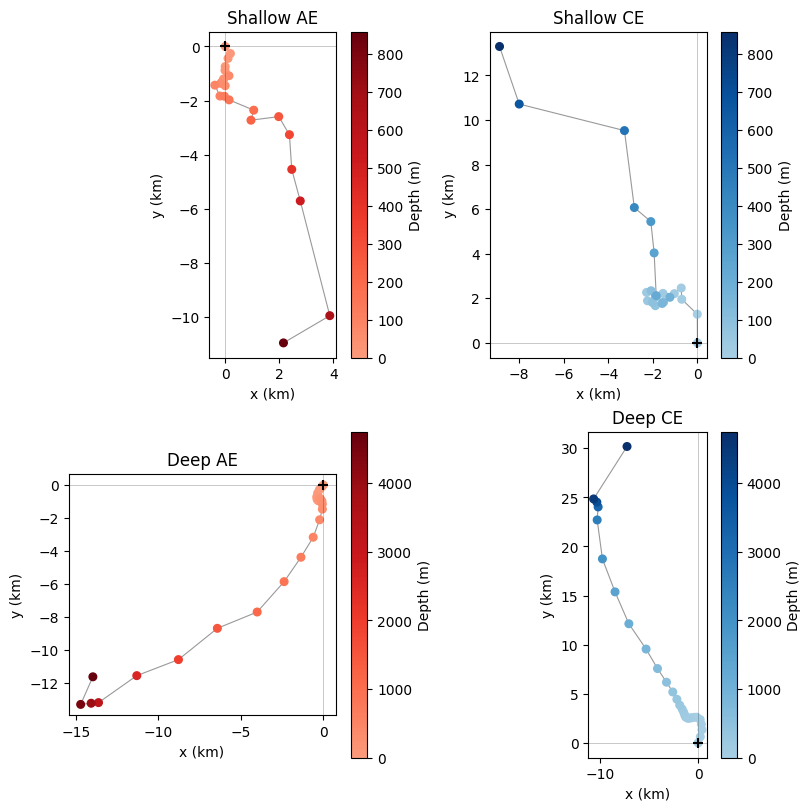

In [49]:
from matplotlib.colors import LinearSegmentedColormap

fig, axs = plt.subplots(2,2,figsize=(8,8),constrained_layout=True)

for i,cohort in enumerate(['shallow','deep']):
    for j,cyc in enumerate(['AE','CE']):
        ax=axs[i,j]
        if (cohort,cyc) not in results: continue

        s=results[cohort,cyc]['stats'].copy()
        s=s[s.n_eddies.ge(MIN_PLOT_EDDIES)].dropna(subset=['mean_east','mean_north','Depth'])
        # cmap=plt.cm.Reds[.45,.95] if cyc=='AE' else plt.cm.Blues
        base = plt.cm.Reds if cyc == 'AE' else plt.cm.Blues
        cmap = LinearSegmentedColormap.from_list(
            f'{cyc}_cmap', base(np.linspace(.35, 1, 256))
        )
        norm=plt.Normalize(s.Depth.min(),s.Depth.max())

        ax.plot(s.mean_east,s.mean_north,color='0.6',lw=.8,zorder=0)
        sc=ax.scatter(s.mean_east,s.mean_north,c=s.Depth,cmap=cmap,norm=norm,s=30)

        ax.scatter(0,0,c='k',marker='+',s=60)
        ax.axhline(0,color='k',lw=.5,alpha=.3)
        ax.axvline(0,color='k',lw=.5,alpha=.3)
        ax.set_aspect('equal')
        ax.set_title(f'{cohort.capitalize()} {cyc}')
        ax.set(xlabel='x (km)',ylabel='y (km)')
        fig.colorbar(sc,ax=ax,label='Depth (m)')

plt.show()